# Тестирование и исправление LSCP 

На задачах для оценки спроса

In [1]:
import random

import osmnx as ox
import geopandas as gpd
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Данные
g = ox.load_graphml("tests/data/test_rng.ml")
g = ox.simplify_graph(g)
area = gpd.read_file("tests/data/test_polygon.gpkg")

# здания
b = gpd.read_file("tests/data/buildings.gpkg", layer='здания')
b = b[['osmid', 'building', 'demand', 'geometry']]   # 'name', 'amenity', 
b = b.set_index('osmid')
print('Всего зданий:', len(b))

nodes = ox.graph_to_gdfs(g, edges=False)
area_nodes = nodes.within(area.iloc[0].geometry)
nodes_list=set(nodes[area_nodes].index)

print('Узлов в графе:', len(nodes))
print('Узлов в пределах area:', len(nodes_list))

Всего зданий: 1591
Узлов в графе: 1941
Узлов в пределах area: 950


In [3]:
print('Проверка СК:', end=' ')
if not g.graph['crs'] == b.crs:
    raise ValueError('CRS G и buildings различны!')
else:
    print('CRS совпадают.')

g = ox.project_graph(g)
b = ox.project_gdf(b)

print('Проверка СК:', end=' ')
if not g.graph['crs'] == b.crs:
    raise ValueError('CRS G и buildings различны!')
else:
    print('CRS совпадают.')

g_nodes = ox.graph_to_gdfs(g, edges=False)
b = b.sjoin_nearest(g_nodes[['geometry']], max_distance=100)
b.rename(columns={'index_right': 'node'}, inplace=True)

Проверка СК: CRS совпадают.
Проверка СК: CRS совпадают.


In [4]:
# Начальное размещение
units_count = 3
start_state = {random.sample(list(nodes_list), k=1)[0]:f'псч {i}' for i in range(units_count)}
start_state

{1998227478: 'псч 0', 2034401608: 'псч 1', 1545616096: 'псч 2'}

In [9]:
# ============================================================================
import warnings
from fire_units.metrics import CoverIndexBuilding, Demand
from genesis.best_points import BestNodeHillClimbing
from genesis.core import BestPointsBase, LSCPBase, PointSelectorBase, StateBase, StopCaseBase
from genesis.lscp import LSCPCommon
from genesis.mclp import BestNodesKoptG
from genesis.metrics import ArrivalTime
from genesis.point_selectors import FarNodeSelector, GenesisNodeSelector, RandomNodesSelector
from genesis.states import FirstArrivalUnitState
from genesis.stop_cases import ItersStopCase, MoreEqualStopCase
from genesis.tools import list_dict_concat
from genesis.utils import TimeCheckPoint, timing

# ============================================================================
# class RandomNodesSelector(PointSelectorBase):
#     '''
#     Простой выбор случайного узла в графе
#     '''
#     def __init__(self, **kwargs) -> None:
#         '''
#         Простой выбор случайного узла в графе
#         '''

#     def __call__(self,
#                 env:nx.MultiDiGraph,
#                 points:dict,
#                 area: pd.Series = None,
#                 nodes_list:set=None,
#                 k:int = 1,
#                 **kwargs):
#         '''
#         Запуск работы алгоритма

#         ## Аргументы
#         `env`:nx.MultiDiGraph
#             Граф улично-дорожной сети
#         `points`: dict
#             Список стартовых узлов графа в которых размещены
#             подразделения.
#         `area`: pd.Series = None
#             Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
#             Если не указана, расчет производится для всех узлов графа.
#         `nodes_list`:set=None
#             Множество узлов графа которые будут рассмотрены в качестве кандидатов.
#             Если не указан, то будут рассмотрены все узлы графа.
#         `k`: int = 1
#             Количество подразделений которые следует добавить.
#         '''

#         # 0. Проверка корректности пришедших данных
#         if not isinstance(env, nx.MultiDiGraph):
#             raise TypeError("Тип аргумента `env` должен быть MultiDiGraph!")
#         if not isinstance(points,dict):
#             raise TypeError(f'Аргумент `points` должен иметь тип: dict'
#                             f'Имеет: {type(points)}')
#         if len(points) < 1:
#             raise ValueError('Аргумент `points` должен содержать хотя бы 1 элемент! ' + \
#                              'В случае если в `env` отсутствуют известные размещения `points`, ' + \
#                              'используйте методы класса `BestPointsBase`')
#         if not area is None and not isinstance(area, pd.Series):
#             raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')
#         if k < 1:
#             raise ValueError(f'Аргумент `k` должен быть >= 1! Имеет: {k}')
        
#         if k != 1:
#             warnings.warn(f'Аргумент `k` не желательно делать отличным от 1! Имеет: {k}. Использовать с осторожностью!')

#         # 1. Выбор случайных n узлов из числа не входящих в points
#         points_set = set(points.keys())
#         # if area is None:
#         #     nodes_set = set(env.nodes()) - points_set
#         # else:
#         #     nodes_set = set(env.nodes()) & set(area[area].keys()) - points_set
#         if nodes_list is None:
#             nodes_set = set(env.nodes()) - points_set
#         else:
#             nodes_set = set(env.nodes()) & nodes_list - points_set            
#         new_nodes = random.choices(list(nodes_set), k=k)

#         # Если нужно получить один узел, возвращаем вместо списка значение int
#         if len(new_nodes)==1:
#             return new_nodes[0]
#         return new_nodes




# class FarNodeSelector(PointSelectorBase):
#     '''
#     Выбор наиболее удаленного от имеющихся размещений узла, 
#     (?) из которого при этом можно попасть
#     в большую часть графа
#     '''
#     def __init__(self,
#                  state_function: StateBase,
#                 #  metric_function: MetricBase,
#                  appr_val: float = 0.5,
#                  weight='travel_time',
#                  **kwargs) -> None:
#         '''
#         ## Аргументы
#         `state_function`: StateBase
#             функция расчета состояния окружения
#         `metric_function`: MetricBase
#             Функция расчета метрики
#         `appr_val`: = 0.5
#             Доля узлов графа, покрытие которой считается приемлемой для принятия расчетной метрики. 
#             Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
#             то такой узел не рассматривается.
#         `weight`:str или callable  = "travel_time"
#             Имя поля содержащего вес ребер, или функция позволяющая вычислять 
#             вес динамически.
#         '''
#         self.state_function = state_function
#         # self.metric_function = metric_function
#         self.appr_val = appr_val
#         self.weight = weight
#         super().__init__(**kwargs)

#     def __call__(self,
#                 env:nx.MultiDiGraph,
#                 points:dict,
#                 area: pd.Series = None,
#                 nodes_list:set=None,
#                 **kwargs):
#         '''
#         Запуск работы алгоритма

#         ## Аргументы
#         `env`:nx.MultiDiGraph
#             Граф улично-дорожной сети
#         `points`: dict
#             Список стартовых узлов графа в которых размещены
#             подразделения.
#         `area`: pd.Series = None
#             Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
#             Если не указана, расчет производится для всех узлов графа.
#         `nodes_list`:set=None
#             Множество узлов графа которые будут рассмотрены в качестве кандидатов.
#             Если не указан, то будут рассмотрены все узлы графа.
#         '''

#         # 0. Проверка корректности пришедших данных
#         if not isinstance(env, nx.MultiDiGraph):
#             raise TypeError("Тип аргумента `env` должен быть MultiDiGraph!")
#         if not isinstance(points,dict):
#             raise TypeError(f'Аргумент `points` должен иметь тип: dict'
#                             f'Имеет: {type(points)}')
#         if not area is None and not isinstance(area, pd.Series):
#             raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')

#         # 1. Расчет состояния прибытия
#         times, _ = self.state_function(env = env,
#                                              points = points,
#                                              area = area,
#                                              **kwargs)

#         # 2. Сортировка узлов по времени прибытия
#         times = times.sort_values(ascending=False)


#         # 3. Последовательный перебор наихудших узлов и оценка достижимости из каждого из них
#         # 3.1. Определение количества допустимых узлов
#         # ... Тут нужно подумать ...
#         if area is None:
#             appr_nodes_count = int(env.number_of_nodes()*self.appr_val)
#         else:
#             appr_nodes_count = int(area.sum()*self.appr_val)
#         # 3.2. Если передан список возможных узлов, то ограничиваемся им
#         # Иначе используем все times
#         if not nodes_list is None:
#             times = times[times.index.isin(nodes_list)]
#         # 3.3. Перебор узлов
#         for node in times.index:
#             node_times, _ = self.state_function(env = env,
#                                                 points = [node],
#                                                 area = area,
#                                                 **kwargs)
#             # print(node, len(node_times), appr_nodes_count)
#             if len(node_times) >= appr_nodes_count:
#                 return node

#         # 4. Если по какой-то причине ни один узел не был найден вызываем ошибку
#         raise LookupError('Не удалось найти ни одного узла')

# class LSCPCommon(LSCPBase):
#     '''
#     Наиболее общий модульный алгоритм расчета количества и оптимального 
#     размещения узлов для достижения целевой метрики.
#     '''
#     def __init__(self,
#                  mclp_function: BestPointsBase,
#                  point_selector: PointSelectorBase,
#                  stop_case_function: StopCaseBase,
#                  names_pattern: str = '{}',
#                  start_names_index: int = 1,
#                  after_mclp_function: callable = None,
#                  **kwargs):
#         self.after_mclp_function = after_mclp_function
#         super().__init__(mclp_function, point_selector, stop_case_function, names_pattern, start_names_index, **kwargs)

#     def __call__(self,
#                  env:nx.MultiDiGraph,
#                  dynamic_nodes: dict,
#                  static_nodes: dict = None,
#                  area: pd.Series = None,
#                  nodes_list:set=None,
#                  **kwargs):
#         '''
#         Запуск работы алгоритма

#         ## Аргументы
#         `env`:nx.MultiDiGraph
#             Граф улично-дорожной сети
#         `dynamic_nodes`: list|dict
#             Список стартовых узлов графа в которых размещены
#             подразделения оптимальные места которых следует определить.
#         `static_nodes`: list|dict = None
#             Список стартовых узлов графа в которых размещены
#             подразделения изменять размещение которых не следует.
#         `area`: pd.Series = None
#             Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
#             Если не указана, расчет производится для всех узлов графа.
#         `nodes_list`:set=None
#             Множество узлов графа которые будут рассмотрены в качестве кандидатов.
#             Если не указан, то будут рассмотрены все узлы графа.
#         '''

#         # 0. Проверка корректности пришедших данных
#         if not isinstance(env, nx.MultiDiGraph):
#             raise TypeError("Тип аргумента `env` должен быть MultiDiGraph!")
#         if not static_nodes is None:
#             if not (isinstance(dynamic_nodes,dict) and isinstance(static_nodes,dict)):
#                 raise TypeError(f'Аргументы `dynamic_nodes` и `static_nodes` должны быть одинакового типа: dict'
#                                 f'Имеют: {type(dynamic_nodes)}, {type(static_nodes)}')
#         if not area is None and not isinstance(area, pd.Series):
#             raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')
      
#         # 0.1. Если статические узлы не указаны - заменяем значение переменной с None на {}
#         if static_nodes is None:
#             static_nodes = {}
#         if len(static_nodes) + len(dynamic_nodes) == 0:
#             raise ValueError('Суммарное количество элементов `static_nodes` и `dynamic_nodes` не может быть равно 0! ' + \
#                             'В случае если в `env` отсутствуют известные размещения `points`, ' + \
#                             'используйте методы класса `BestPointsBase`')

#         # Итерации
#         best_dynamic_nodes = dynamic_nodes
#         iteration = 0
#         name_index = self.start_names_index
#         while True:
#             # 1. Расчет оптимального размещения подразделений
#             best_dynamic_nodes, best_metric = self.mclp_function(env=env,
#                                             dynamic_nodes=best_dynamic_nodes,
#                                             static_nodes=static_nodes,
#                                             area=area,
#                                             **kwargs)
#             if not self.after_mclp_function is None:
#                 self.after_mclp_function(iteration=iteration,
#                             best_metric=best_metric,
#                             dynamic_nodes=best_dynamic_nodes,
#                             static_nodes=static_nodes)

#             # 2. Если достигнута цель расчета, выходим из цикла
#             if self.stop_case_function(value=best_metric,
#                             iteration=iteration,
#                             best_metric=best_metric,
#                             dynamic_nodes=best_dynamic_nodes,
#                             static_nodes=static_nodes):
#                 return best_dynamic_nodes, best_metric

#             # ============================================================================================
#             # 2. Если нет - создаем новое подразделение
#             # 2.1. Получение суммарного списка (или словаря) узлов для расчета состояния и метрик
#             start_nodes = list_dict_concat(best_dynamic_nodes, static_nodes)

#             # 2.2. Выбор нового узла в соответствии с переданной логикой
#             new_node = self.point_selector(env=env, points=start_nodes, area=area, nodes_list=nodes_list)
#             print(new_node)

#             # 2.3. Добавление нового узла в словарь динамических узлов:
#             best_dynamic_nodes[new_node] = self.names_pattern.format(name_index)
#             print(best_dynamic_nodes)

#             # ============================================================================================
#             iteration += 1
#             name_index += 1

#         return best_dynamic_nodes, best_metric



# ============================================================================


# функции метрик спроса
# metric_funct = Demand(b, buildings_demand_field='demand')
# metric_funct = CoverIndexBuilding(b)
# metric_funct = CoverIndexBuilding(b, ip_val=5)
metric_funct = ArrivalTime()

print('\n', '# GNS')
print('-'*80)
t = TimeCheckPoint()
# t2 = TimeCheckPoint()

# здесь сам расчет
def iter_func(i, best_metric, **kwds):
    print(i, ':', best_metric, end='\r')
def mclp_end_function(iteration, best_metric, dynamic_nodes, **kwargs):
    print(f'Итерация: {iteration} |', f'Лучшая метрика: {best_metric} |', f'Подразделений: {len(dynamic_nodes)}')

bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                   metric_function=metric_funct,
                    # metric_function=metric_IPB10,                       
                    )
mclpgns = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                   metric_function=metric_funct,
                #    metric_function=CoverIndex(5),
                    # metric_function=metric_IPB10, 
                    best_point_function=bnhc,
                    iterations=5,
                    iter_calc_end_function=iter_func,
                    )

# Случай остановки
# stop_case = MoreEqualStopCase(95)
stop_case = ItersStopCase(5)

# Селектор следующей точки
point_selector = RandomNodesSelector(nodes_list=nodes_list)
# point_selector = GenesisNodeSelector(state_function = FirstArrivalUnitState(),
#                                     metric_function = metric_funct)
point_selector = FarNodeSelector(FirstArrivalUnitState(), nodes_list=nodes_list)

# Сборка алгоритма
genesis = timing(LSCPCommon(mclp_function = mclpgns,
                    point_selector = point_selector,
                stop_case_function = stop_case,
                start_names_index = 5,
                names_pattern='ПСЧ {}',
                after_mclp_function=mclp_end_function,
                ))
# Собственно применения построенного алгоритма
best_dynamic_nodes, best_metric = genesis(env = g,
                            dynamic_nodes = start_state,
                            area=area_nodes,
                            # nodes_list=nodes_list,
                            # static_nodes = existed_units,
                            )




 # GNS
--------------------------------------------------------------------------------
Итерация: 0 | Лучшая метрика: 2.7742671949420443 | Подразделений: 3
9774067518
{426923872: 'псч 0', 2034401374: 'псч 1', 426923855: 'псч 2', 9774067518: 'ПСЧ 5'}
Итерация: 1 | Лучшая метрика: 2.678122477194039 | Подразделений: 4
4116035978
{426923872: 'псч 0', 2034401374: 'псч 1', 426923855: 'псч 2', 9774067520: 'ПСЧ 5', 4116035978: 'ПСЧ 6'}
Итерация: 2 | Лучшая метрика: 2.664588576245672 | Подразделений: 5
4116025605
{426923872: 'псч 0', 2034401374: 'псч 1', 426923855: 'псч 2', 9774067520: 'ПСЧ 5', 4116037089: 'ПСЧ 6', 4116025605: 'ПСЧ 7'}
Итерация: 3 | Лучшая метрика: 2.6197282348336595 | Подразделений: 6
4116047688
{426923872: 'псч 0', 2034401374: 'псч 1', 426923855: 'псч 2', 9774067520: 'ПСЧ 5', 4116037089: 'ПСЧ 6', 2468412831: 'ПСЧ 7', 4116047688: 'ПСЧ 8'}
Итерация: 4 | Лучшая метрика: 2.549897543579708 | Подразделений: 7
9085465303
{426923872: 'псч 0', 2034401362: 'псч 1', 426923855: 'псч 2',

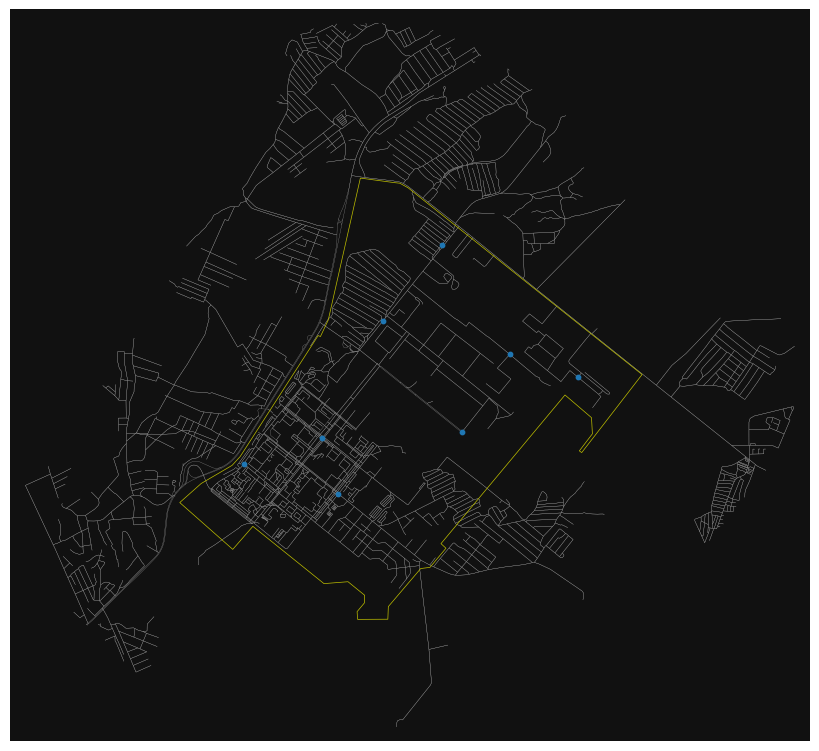

In [10]:
# Сопоставление локальных оптимумов со значениями метрик в них
nodes_gdf = ox.graph_to_gdfs(g, edges=False)
# locals = nodes_gdf.loc[optimums_list].copy()
# locals['demand_metric'] = optimums_metrics
units = nodes_gdf.loc[best_dynamic_nodes.keys()]

# Печать карты
# fig, ax = plt.subplots(1, 1, figsize=(8, 8))
fig, ax = ox.plot_graph(g, node_size=0, edge_linewidth=0.2, show=False)
ox.project_gdf(area).boundary.plot(ax=ax, linewidth=0.5, color='y')
units.plot(ax=ax, markersize=10, legend=True)

plt.tight_layout(pad=0)
plt.show()